<a href="https://colab.research.google.com/github/TingyuZhao19/MSSP6070/blob/main/Assignments/ASSIGNMENT_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
#Connect to my GitHub repository using the file distributed in class
%run '/content/drive/MyDrive/Google_connection.py'

Changed directory to: /content/MSSP6070/MSSP6070


## Load Housing Prices Data

Load the `HousingPrices.csv` dataset from `/content/MSSP6070/data/HousingPrices.csv` into a pandas DataFrame.


In [6]:
import pandas as pd

housing_df = pd.read_csv('/content/MSSP6070/data/HousingPrices.csv')
housing_df.head()

,Id,LotFrontage,LotArea,HouseStyle,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,CentralAir,1stFlrSF,2ndFlrSF,FullBath,TotalRooms,GarageCars,GarageArea,YrSold,SalePrice
0,1,65.0,8450.0,2Story,7,5,2003,856.0,Y,856,854,2,8,2,548,2008,208500
1,2,80.0,9600.0,1Story,6,8,1976,NaN,Y,1262,0,2,6,2,460,2007,181500
2,3,68.0,11250.0,2Story,7,5,2001,920.0,Y,920,866,2,6,2,608,2008,223500
3,4,60.0,9550.0,2Story,7,5,1915,NaN,Y,961,756,1,7,3,642,2006,140000
4,5,84.0,14260.0,2Story,8,5,2000,1145.0,Y,1145,1053,2,9,3,836,2008,250000


## Calculate Descriptive Statistics

Calculate the mean and standard deviation of the housing prices (likely the 'SalePrice' column) from the loaded dataset.


In [7]:
mean_sale_price = housing_df['SalePrice'].mean()
std_sale_price = housing_df['SalePrice'].std()

print(f"Mean SalePrice: {mean_sale_price:.2f}")
print(f"Standard Deviation SalePrice: {std_sale_price:.2f}")

Mean SalePrice: 180921.20
Standard Deviation SalePrice: 79442.50


## Visualize Housing Price Distribution

Generate a histogram of the housing prices, ensuring it has appropriate labels, title, and a legend for clarity.


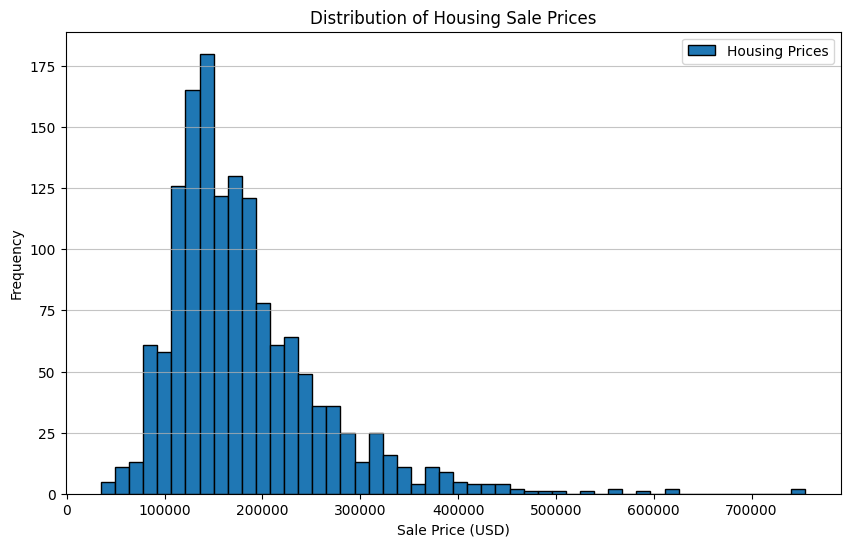

In [8]:
# generate a histogram using matplotlib.pyplot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(housing_df['SalePrice'], bins=50, edgecolor='black', label='Housing Prices')
plt.title('Distribution of Housing Sale Prices')
plt.xlabel('Sale Price (USD)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

## Identify Outliers




To identify outliers in the 'SalePrice' column, I need to calculate the first quartile (Q1), third quartile (Q3), and the Interquartile Range (IQR).



In [9]:
Q1 = housing_df['SalePrice'].quantile(0.25)
Q3 = housing_df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

print(f"First Quartile (Q1): {Q1:.2f}")
print(f"Third Quartile (Q3): {Q3:.2f}")
print(f"Interquartile Range (IQR): {IQR:.2f}")

First Quartile (Q1): 129975.00
Third Quartile (Q3): 214000.00
Interquartile Range (IQR): 84025.00



Now that Q1, Q3, and IQR are calculated, I will define the lower and upper bounds for outlier detection using the IQR method, then identify and count the number of 'SalePrice' values that fall outside these bounds, and print all the calculated values.



In [10]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = housing_df[(housing_df['SalePrice'] < lower_bound) | (housing_df['SalePrice'] > upper_bound)]
num_outliers = outliers.shape[0]

print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")
print(f"Number of Outliers: {num_outliers}")

Lower Bound for Outliers: 3937.50
Upper Bound for Outliers: 340037.50
Number of Outliers: 61
